# Data Analysis

In [89]:
import pandas as pd
import numpy  as np

import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

## Single Stream Str

In [90]:
single_folder_path = '../infra/reports/single_2026-04-16T20:57:54.289715'

### CPU

In [91]:
ds_scpu = pd.read_csv(f'{single_folder_path}/cpu.csv')

ds_scpu['timestamp'] = ds_scpu['timestamp'].apply(lambda x: datetime.fromisoformat(x))
ds_scpu['cpu_mean']  = ds_scpu[['cpu_core_0', 'cpu_core_1', 'cpu_core_2', 'cpu_core_3']].mean(axis=1)

ds_scpu.describe()

,cpu_core_0,cpu_core_1,cpu_core_2,cpu_core_3,cpu_mean
count,1344.000000,1344.000000,1344.000000,1344.000000,1344.000000
mean,26.123512,31.761161,30.923958,25.924107,28.683185
std,19.155358,22.631836,22.217383,19.045422,14.290543
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,16.300000,17.300000,16.800000,16.300000,24.287500
50%,22.400000,30.000000,28.850000,21.400000,36.375000
75%,38.100000,47.500000,46.025000,38.400000,37.225000
max,91.900000,96.900000,92.900000,100.000000,47.525000


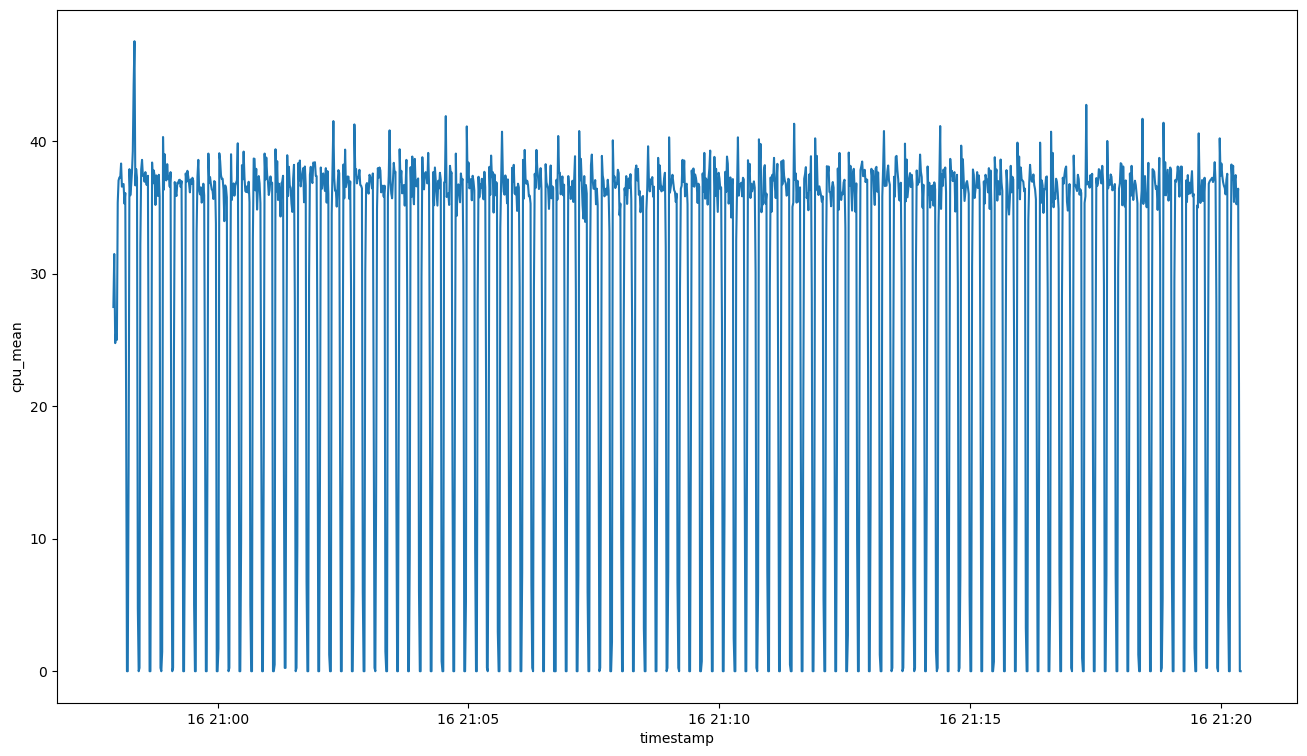

In [92]:
plt.figure(figsize=(16, 9))
sns.lineplot(data=ds_scpu.sort_values(by='timestamp'), x="timestamp", y="cpu_mean")
plt.show()

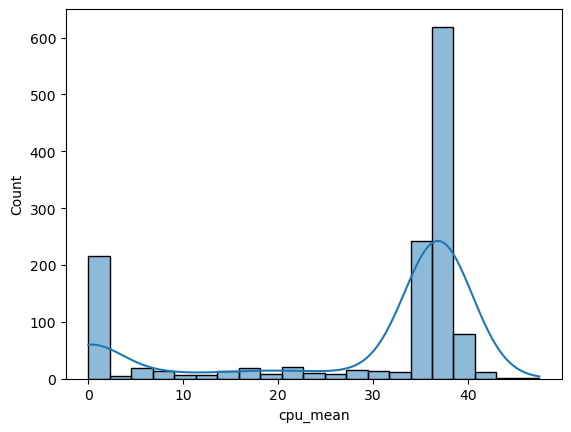

In [93]:
sns.histplot(data=ds_scpu, x="cpu_mean", kde=True)
plt.show()

### RAM

In [94]:
ds_sram = pd.read_csv(f'{single_folder_path}/mem.csv')
ds_sram['timestamp'] = ds_sram['timestamp'].apply(lambda x: datetime.fromisoformat(x))
ds_sram.head()

,timestamp,total,available,used,percent,free,active,inactive,buffers,cached
0,2026-04-16 20:57:54.295770,17002643456,16479748096,522895360,3.1,15638609920,807010304,353517568,40632320,919076864
1,2026-04-16 20:57:55.296311,17002643456,16448012288,554631168,3.3,15606874112,844365824,353517568,40632320,919076864
2,2026-04-16 20:57:56.316862,17002643456,16336879616,665763840,3.9,15495741440,912654336,353517568,40632320,919076864
3,2026-04-16 20:57:57.472619,17002643456,16293068800,709574656,4.2,15451930624,982745088,353517568,40632320,919076864
4,2026-04-16 20:57:58.476418,17002643456,16040067072,962576384,5.7,15198912512,1198522368,353533952,40648704,919076864


### Predict

In [95]:
from pandas import json_normalize
import json

with open(f'{single_folder_path}/metrics.json') as f:
    single_data = json.load(f)

load_model_duration = datetime.fromisoformat(single_data['load_model_final']) - datetime.fromisoformat(single_data['load_model_start'])
    
rows = []
for animal, v1 in single_data['animals'].items():
    row = {
        'pid': single_data['pid'],
        'load_model_start': datetime.fromisoformat(single_data['load_model_start']),
        'load_model_final': datetime.fromisoformat(single_data['load_model_final']),
        'load_model_dur': load_model_duration,
        'animal':animal,
        'first_image_capture_time':datetime.fromisoformat(v1['first_image_capture_time']),
        'last_image_capture_time' :datetime.fromisoformat(v1['last_image_capture_time']),
        'display_time' :datetime.fromisoformat(v1['weight_prediction_final']),
    }
    
    
    for img, v2 in v1['imgs'].items():
        for k, v3 in v2.items():
            row[k] = datetime.fromisoformat(v3)

        rows.append(row)

ds_smetrics_v0 = pd.DataFrame.from_dict(rows)[['pid','load_model_start','load_model_final','load_model_dur','animal','first_image_capture_time','last_image_capture_time','weight_prediction_start','weight_prediction_final','display_time']]
ds_smetrics_v0.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,weight_prediction_start,weight_prediction_final,display_time
0,single_2026-04-16T20:57:54.289715,2026-04-16 20:57:54.295615,2026-04-16 20:57:59.585574,0 days 00:00:05.289959,1,2026-04-16 20:57:59.585688,2026-04-16 20:58:09.131587,2026-04-16 20:58:02.482441,2026-04-16 20:58:03.309364,2026-04-16 20:58:10.101653
1,single_2026-04-16T20:57:54.289715,2026-04-16 20:57:54.295615,2026-04-16 20:57:59.585574,0 days 00:00:05.289959,1,2026-04-16 20:57:59.585688,2026-04-16 20:58:09.131587,2026-04-16 20:58:02.482441,2026-04-16 20:58:03.309364,2026-04-16 20:58:10.101653
2,single_2026-04-16T20:57:54.289715,2026-04-16 20:57:54.295615,2026-04-16 20:57:59.585574,0 days 00:00:05.289959,2,2026-04-16 20:58:13.101782,2026-04-16 20:58:22.693632,2026-04-16 20:58:15.903166,2026-04-16 20:58:16.726129,2026-04-16 20:58:23.662108
3,single_2026-04-16T20:57:54.289715,2026-04-16 20:57:54.295615,2026-04-16 20:57:59.585574,0 days 00:00:05.289959,2,2026-04-16 20:58:13.101782,2026-04-16 20:58:22.693632,2026-04-16 20:58:15.903166,2026-04-16 20:58:16.726129,2026-04-16 20:58:23.662108
4,single_2026-04-16T20:57:54.289715,2026-04-16 20:57:54.295615,2026-04-16 20:57:59.585574,0 days 00:00:05.289959,3,2026-04-16 20:58:26.663823,2026-04-16 20:58:36.160896,2026-04-16 20:58:29.481708,2026-04-16 20:58:30.312130,2026-04-16 20:58:37.127342


In [96]:
ds_smetrics_v0['weight_prediction_dur'] = ds_smetrics_v0['weight_prediction_final'] - ds_smetrics_v0['weight_prediction_start']
ds_smetrics_v0.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,weight_prediction_start,weight_prediction_final,display_time,weight_prediction_dur
0,single_2026-04-16T20:57:54.289715,2026-04-16 20:57:54.295615,2026-04-16 20:57:59.585574,0 days 00:00:05.289959,1,2026-04-16 20:57:59.585688,2026-04-16 20:58:09.131587,2026-04-16 20:58:02.482441,2026-04-16 20:58:03.309364,2026-04-16 20:58:10.101653,0 days 00:00:00.826923
1,single_2026-04-16T20:57:54.289715,2026-04-16 20:57:54.295615,2026-04-16 20:57:59.585574,0 days 00:00:05.289959,1,2026-04-16 20:57:59.585688,2026-04-16 20:58:09.131587,2026-04-16 20:58:02.482441,2026-04-16 20:58:03.309364,2026-04-16 20:58:10.101653,0 days 00:00:00.826923
2,single_2026-04-16T20:57:54.289715,2026-04-16 20:57:54.295615,2026-04-16 20:57:59.585574,0 days 00:00:05.289959,2,2026-04-16 20:58:13.101782,2026-04-16 20:58:22.693632,2026-04-16 20:58:15.903166,2026-04-16 20:58:16.726129,2026-04-16 20:58:23.662108,0 days 00:00:00.822963
3,single_2026-04-16T20:57:54.289715,2026-04-16 20:57:54.295615,2026-04-16 20:57:59.585574,0 days 00:00:05.289959,2,2026-04-16 20:58:13.101782,2026-04-16 20:58:22.693632,2026-04-16 20:58:15.903166,2026-04-16 20:58:16.726129,2026-04-16 20:58:23.662108,0 days 00:00:00.822963
4,single_2026-04-16T20:57:54.289715,2026-04-16 20:57:54.295615,2026-04-16 20:57:59.585574,0 days 00:00:05.289959,3,2026-04-16 20:58:26.663823,2026-04-16 20:58:36.160896,2026-04-16 20:58:29.481708,2026-04-16 20:58:30.312130,2026-04-16 20:58:37.127342,0 days 00:00:00.830422


In [97]:
by_animal_dict = []

for animal, by_animal in ds_smetrics_v0.groupby('animal'):
    # .max() return the most recent date   
    by_animal_lead_time = by_animal['display_time'].max() - by_animal['first_image_capture_time'].iloc[0]
    by_animal_processing_delay = by_animal['weight_prediction_dur'].sum()
    by_animal_latency = by_animal['display_time'].max() - by_animal['last_image_capture_time'].max()
    
    by_animal_dict.append({
        'animal': animal,
        'by_animal_lead_time':by_animal_lead_time,
        'by_animal_processing_delay':by_animal_processing_delay,
        'by_animal_latency':by_animal_latency,
    })

ds_smetrics_v1 = ds_smetrics_v0.merge(
    pd.DataFrame.from_records(by_animal_dict),
    on='animal'
)
ds_smetrics_v1.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,weight_prediction_start,weight_prediction_final,display_time,weight_prediction_dur,by_animal_lead_time,by_animal_processing_delay,by_animal_latency
0,single_2026-04-16T20:57:54.289715,2026-04-16 20:57:54.295615,2026-04-16 20:57:59.585574,0 days 00:00:05.289959,1,2026-04-16 20:57:59.585688,2026-04-16 20:58:09.131587,2026-04-16 20:58:02.482441,2026-04-16 20:58:03.309364,2026-04-16 20:58:10.101653,0 days 00:00:00.826923,0 days 00:00:10.515965,0 days 00:00:01.653846,0 days 00:00:00.970066
1,single_2026-04-16T20:57:54.289715,2026-04-16 20:57:54.295615,2026-04-16 20:57:59.585574,0 days 00:00:05.289959,1,2026-04-16 20:57:59.585688,2026-04-16 20:58:09.131587,2026-04-16 20:58:02.482441,2026-04-16 20:58:03.309364,2026-04-16 20:58:10.101653,0 days 00:00:00.826923,0 days 00:00:10.515965,0 days 00:00:01.653846,0 days 00:00:00.970066
2,single_2026-04-16T20:57:54.289715,2026-04-16 20:57:54.295615,2026-04-16 20:57:59.585574,0 days 00:00:05.289959,2,2026-04-16 20:58:13.101782,2026-04-16 20:58:22.693632,2026-04-16 20:58:15.903166,2026-04-16 20:58:16.726129,2026-04-16 20:58:23.662108,0 days 00:00:00.822963,0 days 00:00:10.560326,0 days 00:00:01.645926,0 days 00:00:00.968476
3,single_2026-04-16T20:57:54.289715,2026-04-16 20:57:54.295615,2026-04-16 20:57:59.585574,0 days 00:00:05.289959,2,2026-04-16 20:58:13.101782,2026-04-16 20:58:22.693632,2026-04-16 20:58:15.903166,2026-04-16 20:58:16.726129,2026-04-16 20:58:23.662108,0 days 00:00:00.822963,0 days 00:00:10.560326,0 days 00:00:01.645926,0 days 00:00:00.968476
4,single_2026-04-16T20:57:54.289715,2026-04-16 20:57:54.295615,2026-04-16 20:57:59.585574,0 days 00:00:05.289959,3,2026-04-16 20:58:26.663823,2026-04-16 20:58:36.160896,2026-04-16 20:58:29.481708,2026-04-16 20:58:30.312130,2026-04-16 20:58:37.127342,0 days 00:00:00.830422,0 days 00:00:10.463519,0 days 00:00:01.660844,0 days 00:00:00.966446


In [98]:
collect_lead_time = ds_smetrics_v1['display_time'].max() - ds_smetrics_v1['first_image_capture_time'].min()
qtt = len(ds_smetrics_v1['animal'].unique())

ds_smetrics_v1['collect_lead_time'] = collect_lead_time
ds_smetrics_v1['mean_throughput'] = qtt / (collect_lead_time.total_seconds() / 60 / 60) # hour

ds_smetrics_v1.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,weight_prediction_start,weight_prediction_final,display_time,weight_prediction_dur,by_animal_lead_time,by_animal_processing_delay,by_animal_latency,collect_lead_time,mean_throughput
0,single_2026-04-16T20:57:54.289715,2026-04-16 20:57:54.295615,2026-04-16 20:57:59.585574,0 days 00:00:05.289959,1,2026-04-16 20:57:59.585688,2026-04-16 20:58:09.131587,2026-04-16 20:58:02.482441,2026-04-16 20:58:03.309364,2026-04-16 20:58:10.101653,0 days 00:00:00.826923,0 days 00:00:10.515965,0 days 00:00:01.653846,0 days 00:00:00.970066,0 days 00:22:21.767101,268.302897
1,single_2026-04-16T20:57:54.289715,2026-04-16 20:57:54.295615,2026-04-16 20:57:59.585574,0 days 00:00:05.289959,1,2026-04-16 20:57:59.585688,2026-04-16 20:58:09.131587,2026-04-16 20:58:02.482441,2026-04-16 20:58:03.309364,2026-04-16 20:58:10.101653,0 days 00:00:00.826923,0 days 00:00:10.515965,0 days 00:00:01.653846,0 days 00:00:00.970066,0 days 00:22:21.767101,268.302897
2,single_2026-04-16T20:57:54.289715,2026-04-16 20:57:54.295615,2026-04-16 20:57:59.585574,0 days 00:00:05.289959,2,2026-04-16 20:58:13.101782,2026-04-16 20:58:22.693632,2026-04-16 20:58:15.903166,2026-04-16 20:58:16.726129,2026-04-16 20:58:23.662108,0 days 00:00:00.822963,0 days 00:00:10.560326,0 days 00:00:01.645926,0 days 00:00:00.968476,0 days 00:22:21.767101,268.302897
3,single_2026-04-16T20:57:54.289715,2026-04-16 20:57:54.295615,2026-04-16 20:57:59.585574,0 days 00:00:05.289959,2,2026-04-16 20:58:13.101782,2026-04-16 20:58:22.693632,2026-04-16 20:58:15.903166,2026-04-16 20:58:16.726129,2026-04-16 20:58:23.662108,0 days 00:00:00.822963,0 days 00:00:10.560326,0 days 00:00:01.645926,0 days 00:00:00.968476,0 days 00:22:21.767101,268.302897
4,single_2026-04-16T20:57:54.289715,2026-04-16 20:57:54.295615,2026-04-16 20:57:59.585574,0 days 00:00:05.289959,3,2026-04-16 20:58:26.663823,2026-04-16 20:58:36.160896,2026-04-16 20:58:29.481708,2026-04-16 20:58:30.312130,2026-04-16 20:58:37.127342,0 days 00:00:00.830422,0 days 00:00:10.463519,0 days 00:00:01.660844,0 days 00:00:00.966446,0 days 00:22:21.767101,268.302897


### Power

In [99]:
ds_spower = pd.read_csv(f'{single_folder_path}/single.csv')
ds_spower['timestamp'] = ds_spower['Datetime'].apply(lambda x: datetime.fromisoformat(x))
ds_spower.head()

,Datetime,Time[S],Volt[V],Current[A],Power[W],timestamp
0,2026-04-16T20:57:50.362923,0.0,5.1091,0.56204,2.8664,2026-04-16 20:57:50.362923
1,2026-04-16T20:57:51.379049,1.0,5.1059,0.70579,3.5995,2026-04-16 20:57:51.379049
2,2026-04-16T20:57:52.355608,2.0,5.1090,0.90441,4.6124,2026-04-16 20:57:52.355608
3,2026-04-16T20:57:53.379239,3.0,5.1091,0.90187,4.5995,2026-04-16 20:57:53.379239
4,2026-04-16T20:57:54.355178,4.0,5.1117,0.92278,4.7154,2026-04-16 20:57:54.355178


In [100]:
ds_spower = ds_spower.sort_values('timestamp')

# Time difference in hours
ds_spower['dt_hours'] = ds_spower['timestamp'].diff().dt.total_seconds() / 3600

# Energy (Wh)
ds_spower['energy_Wh'] = ds_spower['Power[W]'] * ds_spower['dt_hours']

# Total energy
total_energy_Wh = ds_spower['energy_Wh'].sum()

print("Total energy (Wh):", total_energy_Wh)
print("Total energy (kWh):", total_energy_Wh / 1000)

Total energy (Wh): 1.965047843542139
Total energy (kWh): 0.001965047843542139


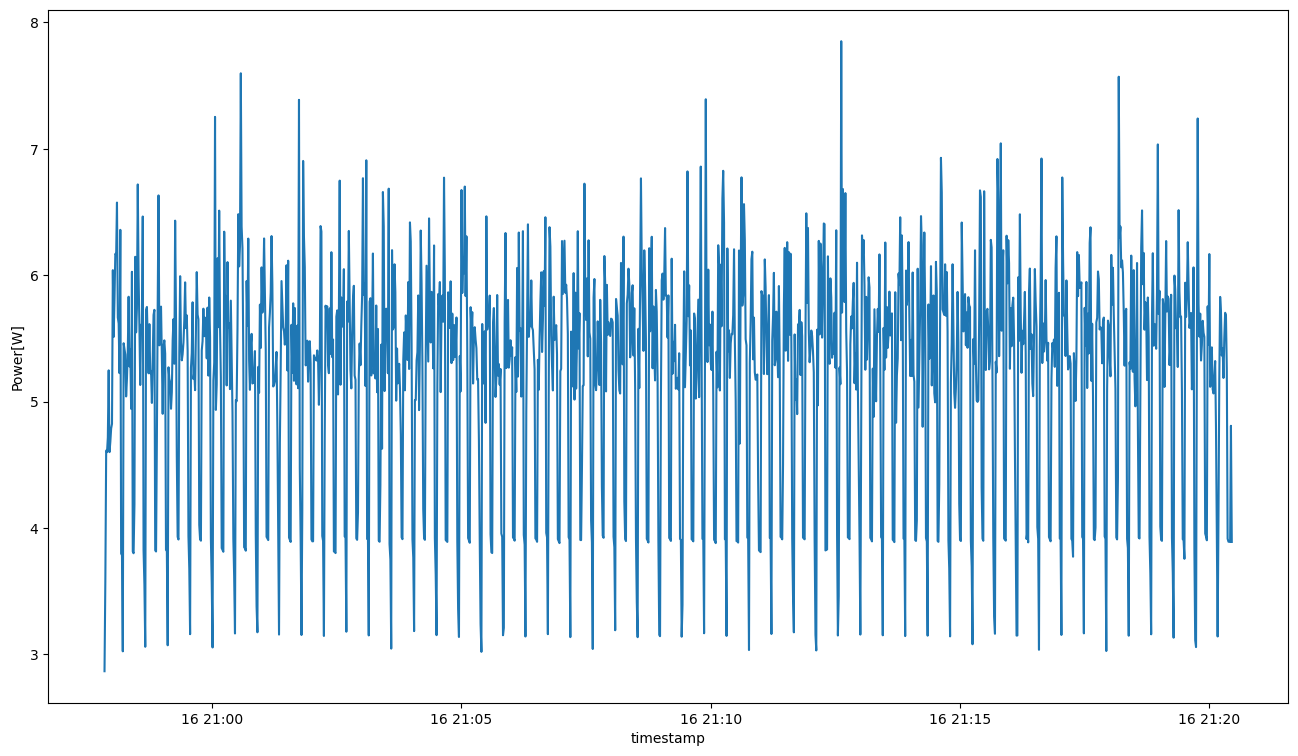

In [101]:
plt.figure(figsize=(16, 9))
sns.lineplot(data=ds_spower.sort_values(by='timestamp'), x="timestamp", y="Power[W]")
plt.show()

## Batch Stream Str

In [102]:
batch_folder_path = '../infra/reports/batch_2026-04-16T21:21:13.102667'

### CPU

In [103]:
ds_bcpu = pd.read_csv(f'{batch_folder_path}/cpu.csv')

ds_bcpu['timestamp'] = ds_bcpu['timestamp'].apply(lambda x: datetime.fromisoformat(x))
ds_bcpu['cpu_mean']  = ds_bcpu[['cpu_core_0', 'cpu_core_1', 'cpu_core_2', 'cpu_core_3']].mean(axis=1)

ds_bcpu.describe()

,cpu_core_0,cpu_core_1,cpu_core_2,cpu_core_3,cpu_mean
count,1530.000000,1530.000000,1530.000000,1530.000000,1530.000000
mean,29.409216,34.294118,34.283333,28.687516,31.668546
std,19.882248,22.612125,22.574165,19.402514,15.481262
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.300000,18.600000,18.650000,17.600000,34.637500
50%,26.000000,33.500000,33.300000,24.100000,36.500000
75%,43.100000,51.000000,51.000000,42.000000,37.350000
max,89.800000,100.000000,91.900000,100.000000,65.525000


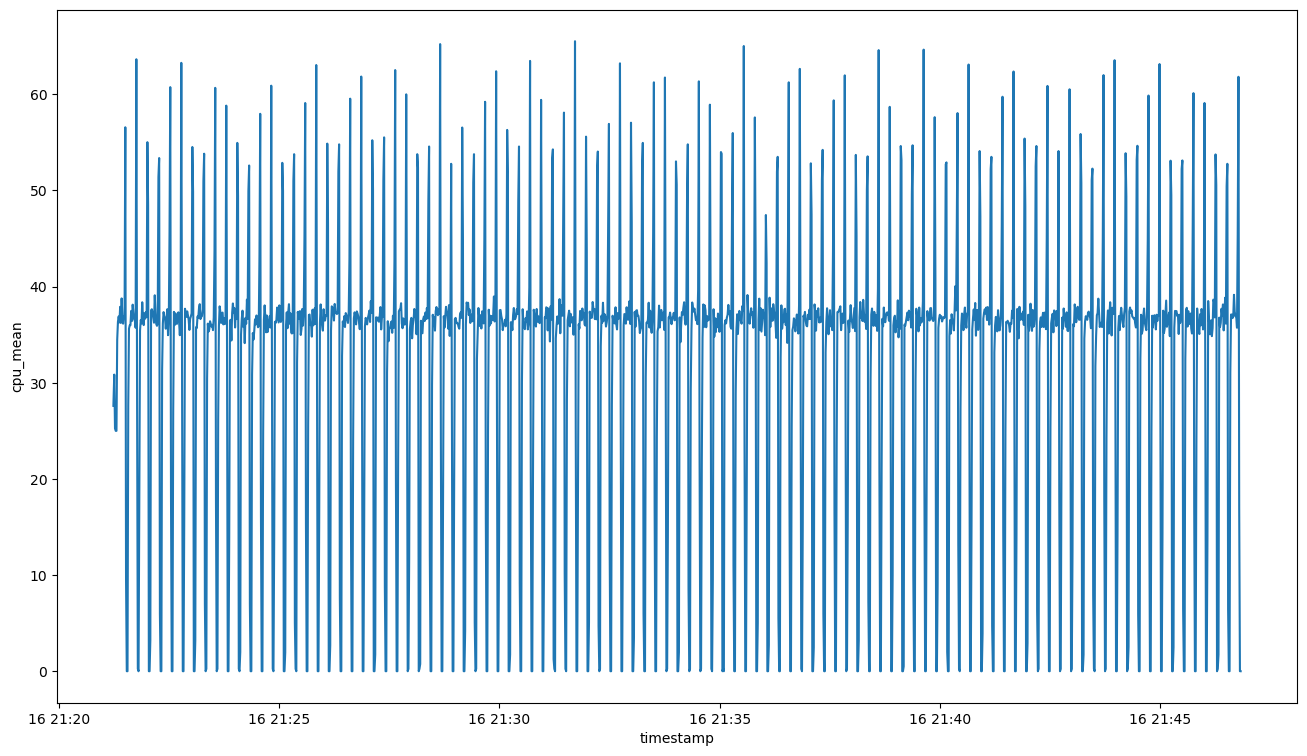

In [104]:
plt.figure(figsize=(16, 9))
sns.lineplot(data=ds_bcpu.sort_values(by='timestamp'), x="timestamp", y="cpu_mean")
plt.show()

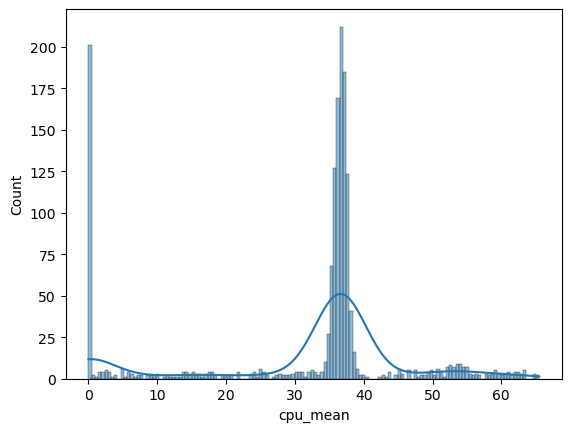

In [105]:
sns.histplot(data=ds_bcpu, x="cpu_mean", kde=True)
plt.show()

### RAM

In [106]:
ds_bram = pd.read_csv(f'{batch_folder_path}/mem.csv')
ds_bram['timestamp'] = ds_bram['timestamp'].apply(lambda x: datetime.fromisoformat(x))
ds_bram.describe()

,total,available,used,percent,free,active,inactive,buffers,cached
count,1.533000e+03,1.533000e+03,1.533000e+03,1533.000000,1.533000e+03,1.533000e+03,1.533000e+03,1.533000e+03,1.533000e+03
mean,1.700264e+10,1.565263e+10,1.350009e+09,7.938487,1.480850e+10,1.479013e+09,3.543749e+08,4.110134e+07,9.217255e+08
std,0.000000e+00,2.893737e+08,2.893737e+08,1.702664,2.893825e+08,2.940684e+08,7.973069e+04,4.460815e+04,2.045523e+05
min,1.700264e+10,1.509681e+10,5.352161e+08,3.100000,1.425306e+10,8.097300e+08,3.542057e+08,4.100915e+07,9.212232e+08
25%,1.700264e+10,1.533357e+10,1.146405e+09,6.700000,1.448929e+10,1.291518e+09,3.542548e+08,4.104192e+07,9.213870e+08
50%,1.700264e+10,1.579768e+10,1.204961e+09,7.100000,1.495351e+10,1.294549e+09,3.544187e+08,4.112384e+07,9.218458e+08
75%,1.700264e+10,1.585624e+10,1.669071e+09,9.800000,1.501197e+10,1.808155e+09,3.544187e+08,4.112384e+07,9.218458e+08
max,1.700264e+10,1.646743e+10,1.905836e+09,11.200000,1.562386e+10,1.988051e+09,3.544678e+08,4.117299e+07,9.219768e+08


### Predict

In [107]:
import json

with open(f'{batch_folder_path}/metrics.json') as f:
    batch_data = json.load(f)

load_model_duration = datetime.fromisoformat(batch_data['load_model_final']) - datetime.fromisoformat(batch_data['load_model_start'])

rows = []
for animal, v1 in batch_data['animals'].items():
    row = {
        'pid': batch_data['pid'],
        'load_model_start': datetime.fromisoformat(batch_data['load_model_start']),
        'load_model_final': datetime.fromisoformat(batch_data['load_model_final']),
        'load_model_dur': load_model_duration,
        'animal':animal,
        'first_image_capture_time':datetime.fromisoformat(v1['first_image_capture_time']),
        'last_image_capture_time' :datetime.fromisoformat(v1['last_image_capture_time']),
        'display_time' :datetime.fromisoformat(v1['weight_prediction_final']),
    }
    
    
    for img, v2 in v1['imgs'].items():
        for k, v3 in v2.items():
            row[k] = datetime.fromisoformat(v3)

        rows.append(row)

ds_bmetrics_v0 = pd.DataFrame.from_dict(rows)[['pid','load_model_start','load_model_final','load_model_dur','animal','first_image_capture_time','last_image_capture_time','weight_prediction_start','weight_prediction_final','display_time']]
ds_bmetrics_v0.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,weight_prediction_start,weight_prediction_final,display_time
0,batch_2026-04-16T21:21:13.102667,2026-04-16 21:21:13.108632,2026-04-16 21:21:18.411078,0 days 00:00:05.302446,1,2026-04-16 21:21:18.412095,2026-04-16 21:21:28.338481,2026-04-16 21:21:29.312427,2026-04-16 21:21:30.617484,2026-04-16 21:21:30.617571
1,batch_2026-04-16T21:21:13.102667,2026-04-16 21:21:13.108632,2026-04-16 21:21:18.411078,0 days 00:00:05.302446,2,2026-04-16 21:21:33.619286,2026-04-16 21:21:43.449815,2026-04-16 21:21:44.425878,2026-04-16 21:21:45.951177,2026-04-16 21:21:45.951249
2,batch_2026-04-16T21:21:13.102667,2026-04-16 21:21:13.108632,2026-04-16 21:21:18.411078,0 days 00:00:05.302446,3,2026-04-16 21:21:48.952845,2026-04-16 21:21:58.783802,2026-04-16 21:21:59.758226,2026-04-16 21:22:01.282829,2026-04-16 21:22:01.282895
3,batch_2026-04-16T21:21:13.102667,2026-04-16 21:21:13.108632,2026-04-16 21:21:18.411078,0 days 00:00:05.302446,4,2026-04-16 21:22:04.284495,2026-04-16 21:22:14.095824,2026-04-16 21:22:15.069218,2026-04-16 21:22:16.591992,2026-04-16 21:22:16.592059
4,batch_2026-04-16T21:21:13.102667,2026-04-16 21:21:13.108632,2026-04-16 21:21:18.411078,0 days 00:00:05.302446,5,2026-04-16 21:22:19.593625,2026-04-16 21:22:29.409384,2026-04-16 21:22:30.382796,2026-04-16 21:22:31.901148,2026-04-16 21:22:31.901216


In [108]:
ds_bmetrics_v0['by_animal_lead_time'] = ds_bmetrics_v0['display_time'] - ds_bmetrics_v0['first_image_capture_time']
ds_bmetrics_v0['by_animal_processing_delay'] = ds_bmetrics_v0['weight_prediction_final'] - ds_bmetrics_v0['weight_prediction_start']
ds_bmetrics_v0['by_animal_latency'] = ds_bmetrics_v0['display_time'] - ds_bmetrics_v0['last_image_capture_time']

ds_bmetrics_v0.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,weight_prediction_start,weight_prediction_final,display_time,by_animal_lead_time,by_animal_processing_delay,by_animal_latency
0,batch_2026-04-16T21:21:13.102667,2026-04-16 21:21:13.108632,2026-04-16 21:21:18.411078,0 days 00:00:05.302446,1,2026-04-16 21:21:18.412095,2026-04-16 21:21:28.338481,2026-04-16 21:21:29.312427,2026-04-16 21:21:30.617484,2026-04-16 21:21:30.617571,0 days 00:00:12.205476,0 days 00:00:01.305057,0 days 00:00:02.279090
1,batch_2026-04-16T21:21:13.102667,2026-04-16 21:21:13.108632,2026-04-16 21:21:18.411078,0 days 00:00:05.302446,2,2026-04-16 21:21:33.619286,2026-04-16 21:21:43.449815,2026-04-16 21:21:44.425878,2026-04-16 21:21:45.951177,2026-04-16 21:21:45.951249,0 days 00:00:12.331963,0 days 00:00:01.525299,0 days 00:00:02.501434
2,batch_2026-04-16T21:21:13.102667,2026-04-16 21:21:13.108632,2026-04-16 21:21:18.411078,0 days 00:00:05.302446,3,2026-04-16 21:21:48.952845,2026-04-16 21:21:58.783802,2026-04-16 21:21:59.758226,2026-04-16 21:22:01.282829,2026-04-16 21:22:01.282895,0 days 00:00:12.330050,0 days 00:00:01.524603,0 days 00:00:02.499093
3,batch_2026-04-16T21:21:13.102667,2026-04-16 21:21:13.108632,2026-04-16 21:21:18.411078,0 days 00:00:05.302446,4,2026-04-16 21:22:04.284495,2026-04-16 21:22:14.095824,2026-04-16 21:22:15.069218,2026-04-16 21:22:16.591992,2026-04-16 21:22:16.592059,0 days 00:00:12.307564,0 days 00:00:01.522774,0 days 00:00:02.496235
4,batch_2026-04-16T21:21:13.102667,2026-04-16 21:21:13.108632,2026-04-16 21:21:18.411078,0 days 00:00:05.302446,5,2026-04-16 21:22:19.593625,2026-04-16 21:22:29.409384,2026-04-16 21:22:30.382796,2026-04-16 21:22:31.901148,2026-04-16 21:22:31.901216,0 days 00:00:12.307591,0 days 00:00:01.518352,0 days 00:00:02.491832


In [109]:
collect_lead_time = ds_bmetrics_v0['display_time'].max() - ds_bmetrics_v0['first_image_capture_time'].min()
qtt = len(ds_bmetrics_v0['animal'].unique())

ds_bmetrics_v0['collect_lead_time'] = collect_lead_time
ds_bmetrics_v0['mean_throughput'] = qtt / (collect_lead_time.total_seconds() / 60 / 60) # hour

ds_bmetrics_v0.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,weight_prediction_start,weight_prediction_final,display_time,by_animal_lead_time,by_animal_processing_delay,by_animal_latency,collect_lead_time,mean_throughput
0,batch_2026-04-16T21:21:13.102667,2026-04-16 21:21:13.108632,2026-04-16 21:21:18.411078,0 days 00:00:05.302446,1,2026-04-16 21:21:18.412095,2026-04-16 21:21:28.338481,2026-04-16 21:21:29.312427,2026-04-16 21:21:30.617484,2026-04-16 21:21:30.617571,0 days 00:00:12.205476,0 days 00:00:01.305057,0 days 00:00:02.279090,0 days 00:25:28.466990,235.530111
1,batch_2026-04-16T21:21:13.102667,2026-04-16 21:21:13.108632,2026-04-16 21:21:18.411078,0 days 00:00:05.302446,2,2026-04-16 21:21:33.619286,2026-04-16 21:21:43.449815,2026-04-16 21:21:44.425878,2026-04-16 21:21:45.951177,2026-04-16 21:21:45.951249,0 days 00:00:12.331963,0 days 00:00:01.525299,0 days 00:00:02.501434,0 days 00:25:28.466990,235.530111
2,batch_2026-04-16T21:21:13.102667,2026-04-16 21:21:13.108632,2026-04-16 21:21:18.411078,0 days 00:00:05.302446,3,2026-04-16 21:21:48.952845,2026-04-16 21:21:58.783802,2026-04-16 21:21:59.758226,2026-04-16 21:22:01.282829,2026-04-16 21:22:01.282895,0 days 00:00:12.330050,0 days 00:00:01.524603,0 days 00:00:02.499093,0 days 00:25:28.466990,235.530111
3,batch_2026-04-16T21:21:13.102667,2026-04-16 21:21:13.108632,2026-04-16 21:21:18.411078,0 days 00:00:05.302446,4,2026-04-16 21:22:04.284495,2026-04-16 21:22:14.095824,2026-04-16 21:22:15.069218,2026-04-16 21:22:16.591992,2026-04-16 21:22:16.592059,0 days 00:00:12.307564,0 days 00:00:01.522774,0 days 00:00:02.496235,0 days 00:25:28.466990,235.530111
4,batch_2026-04-16T21:21:13.102667,2026-04-16 21:21:13.108632,2026-04-16 21:21:18.411078,0 days 00:00:05.302446,5,2026-04-16 21:22:19.593625,2026-04-16 21:22:29.409384,2026-04-16 21:22:30.382796,2026-04-16 21:22:31.901148,2026-04-16 21:22:31.901216,0 days 00:00:12.307591,0 days 00:00:01.518352,0 days 00:00:02.491832,0 days 00:25:28.466990,235.530111


### Power

In [110]:
ds_bpower = pd.read_csv(f'{batch_folder_path}/batch.csv')

ds_bpower['timestamp'] = ds_bpower['Datetime'].apply(lambda x: datetime.fromisoformat(x))

ds_bpower.head()

,Datetime,Time[S],Volt[V],Current[A],Power[W],timestamp
0,2026-04-16T21:21:09.744406,0.0,5.1100,0.58252,2.9766,2026-04-16 21:21:09.744406
1,2026-04-16T21:21:10.715101,1.0,5.1097,0.93047,4.7453,2026-04-16 21:21:10.715101
2,2026-04-16T21:21:11.734718,2.0,5.1098,0.91264,4.6544,2026-04-16 21:21:11.734718
3,2026-04-16T21:21:12.708474,3.0,5.1096,0.92979,4.7419,2026-04-16 21:21:12.708474
4,2026-04-16T21:21:13.728651,4.0,5.1100,0.92413,4.7223,2026-04-16 21:21:13.728651


In [111]:
ds_bpower = ds_bpower.sort_values('timestamp')

# Time difference in hours
ds_bpower['dt_hours'] = ds_bpower['timestamp'].diff().dt.total_seconds() / 3600

# Energy (Wh)
ds_bpower['energy_Wh'] = ds_bpower['Power[W]'] * ds_bpower['dt_hours']

# Total energy
total_energy_Wh = ds_bpower['energy_Wh'].sum()

print("Total energy (Wh):", total_energy_Wh)
print("Total energy (kWh):", total_energy_Wh / 1000)

Total energy (Wh): 2.326380672619861
Total energy (kWh): 0.002326380672619861


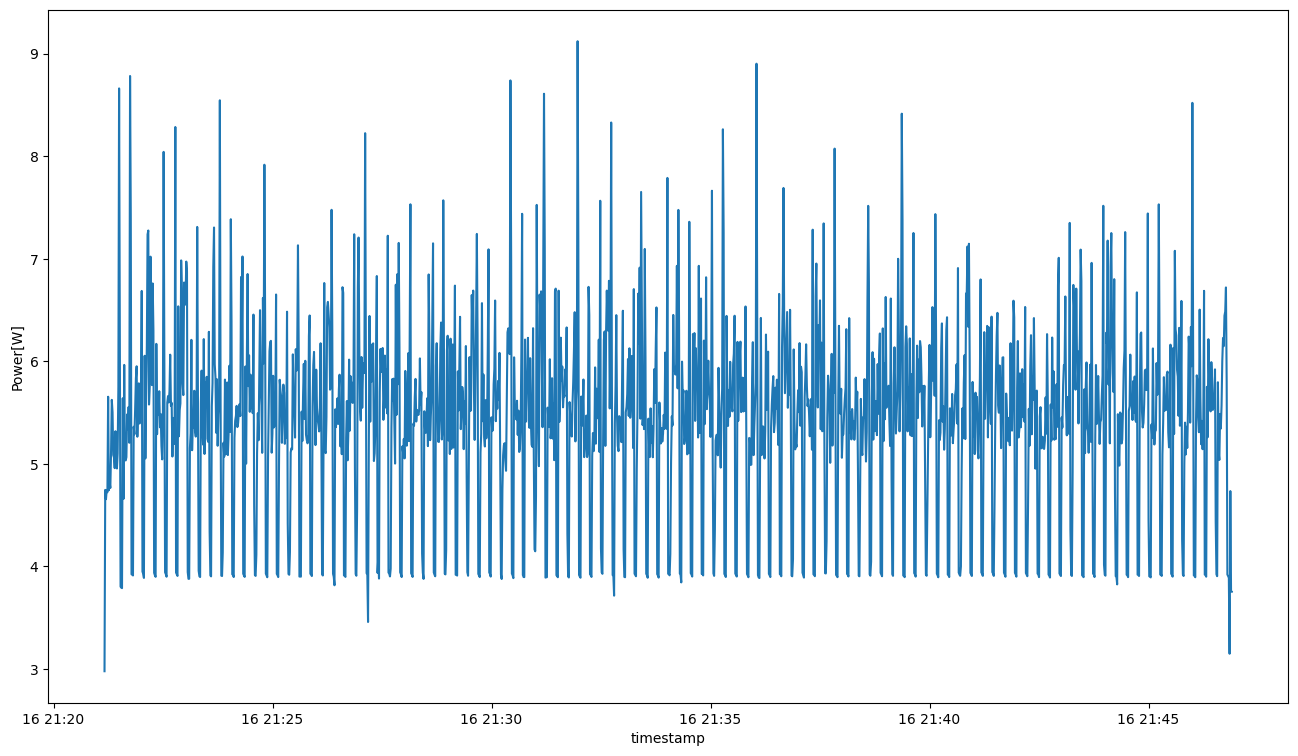

In [112]:
plt.figure(figsize=(16, 9))
sns.lineplot(data=ds_bpower.sort_values(by='timestamp'), x="timestamp", y="Power[W]")
plt.show()

## Comparing

### Metrics

In [123]:
ds_smetrics_v1[['by_animal_latency','by_animal_processing_delay','collect_lead_time','mean_throughput']].describe()
# 9 imgs por animal
# 2 suited
# 9 * 100 animais / ??min => 0.?? FPS

,by_animal_latency,by_animal_processing_delay,collect_lead_time,mean_throughput
count,200,200,200,2.000000e+02
mean,0 days 00:00:00.972785790,0 days 00:00:01.655831360,0 days 00:22:21.767101,2.683029e+02
std,0 days 00:00:00.007258636,0 days 00:00:00.004381771,0 days 00:00:00,6.838328e-13
min,0 days 00:00:00.963179,0 days 00:00:01.645926,0 days 00:22:21.767101,2.683029e+02
25%,0 days 00:00:00.967657500,0 days 00:00:01.653243,0 days 00:22:21.767101,2.683029e+02
50%,0 days 00:00:00.969119,0 days 00:00:01.655327,0 days 00:22:21.767101,2.683029e+02
75%,0 days 00:00:00.980330,0 days 00:00:01.658922,0 days 00:22:21.767101,2.683029e+02
max,0 days 00:00:00.994642,0 days 00:00:01.665578,0 days 00:22:21.767101,2.683029e+02


In [114]:
ds_smetrics_v1['by_animal_processing_delay'].sum()

Timedelta('0 days 00:05:31.166272')

In [115]:
ds_bmetrics_v0[['by_animal_latency','by_animal_processing_delay','collect_lead_time','mean_throughput']].describe()
# 11 imgs por animal
# 4 suited
# 11 * 100 animais / ??min => ??? FPS

,by_animal_latency,by_animal_processing_delay,collect_lead_time,mean_throughput
count,100,100,100,1.000000e+02
mean,0 days 00:00:02.486994950,0 days 00:00:01.505067630,0 days 00:25:28.466990,2.355301e+02
std,0 days 00:00:00.043535319,0 days 00:00:00.043673530,0 days 00:00:00,1.999542e-13
min,0 days 00:00:02.262477,0 days 00:00:01.287609,0 days 00:25:28.466990,2.355301e+02
25%,0 days 00:00:02.488011250,0 days 00:00:01.510722250,0 days 00:25:28.466990,2.355301e+02
50%,0 days 00:00:02.496728500,0 days 00:00:01.512884500,0 days 00:25:28.466990,2.355301e+02
75%,0 days 00:00:02.500905250,0 days 00:00:01.516248250,0 days 00:25:28.466990,2.355301e+02
max,0 days 00:00:02.512095,0 days 00:00:01.527031,0 days 00:25:28.466990,2.355301e+02


In [116]:
ds_bmetrics_v0['by_animal_processing_delay'].sum()

Timedelta('0 days 00:02:30.506763')

### CPU

In [117]:
ds_scpu.describe()

,cpu_core_0,cpu_core_1,cpu_core_2,cpu_core_3,cpu_mean
count,1344.000000,1344.000000,1344.000000,1344.000000,1344.000000
mean,26.123512,31.761161,30.923958,25.924107,28.683185
std,19.155358,22.631836,22.217383,19.045422,14.290543
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,16.300000,17.300000,16.800000,16.300000,24.287500
50%,22.400000,30.000000,28.850000,21.400000,36.375000
75%,38.100000,47.500000,46.025000,38.400000,37.225000
max,91.900000,96.900000,92.900000,100.000000,47.525000


In [118]:
ds_bcpu.describe()

,cpu_core_0,cpu_core_1,cpu_core_2,cpu_core_3,cpu_mean
count,1530.000000,1530.000000,1530.000000,1530.000000,1530.000000
mean,29.409216,34.294118,34.283333,28.687516,31.668546
std,19.882248,22.612125,22.574165,19.402514,15.481262
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.300000,18.600000,18.650000,17.600000,34.637500
50%,26.000000,33.500000,33.300000,24.100000,36.500000
75%,43.100000,51.000000,51.000000,42.000000,37.350000
max,89.800000,100.000000,91.900000,100.000000,65.525000


### RAM

In [119]:
ds_sram.describe()

,total,available,used,percent,free,active,inactive,buffers,cached
count,1.347000e+03,1.347000e+03,1.347000e+03,1347.000000,1.347000e+03,1.347000e+03,1.347000e+03,1.347000e+03,1.347000e+03
mean,1.700264e+10,1.602617e+10,9.764744e+08,5.717817,1.518472e+10,1.285605e+09,3.537533e+08,4.086750e+07,9.192436e+08
std,0.000000e+00,2.624343e+07,2.624343e+07,0.156893,2.623107e+07,2.231404e+07,8.571009e+04,8.108816e+04,4.416357e+04
min,1.700264e+10,1.583707e+10,5.228954e+08,3.100000,1.499591e+10,8.070103e+08,3.535176e+08,4.063232e+07,9.190769e+08
25%,1.700264e+10,1.602676e+10,9.738977e+08,5.700000,1.518527e+10,1.285947e+09,3.537469e+08,4.086170e+07,9.192571e+08
50%,1.700264e+10,1.602802e+10,9.746186e+08,5.700000,1.518656e+10,1.287324e+09,3.537633e+08,4.087808e+07,9.192571e+08
75%,1.700264e+10,1.602875e+10,9.758884e+08,5.700000,1.518733e+10,1.288012e+09,3.537797e+08,4.089446e+07,9.192571e+08
max,1.700264e+10,1.647975e+10,1.165574e+09,6.900000,1.563861e+10,1.304625e+09,3.538616e+08,4.096000e+07,9.194209e+08


In [120]:
ds_bram.describe()

,total,available,used,percent,free,active,inactive,buffers,cached
count,1.533000e+03,1.533000e+03,1.533000e+03,1533.000000,1.533000e+03,1.533000e+03,1.533000e+03,1.533000e+03,1.533000e+03
mean,1.700264e+10,1.565263e+10,1.350009e+09,7.938487,1.480850e+10,1.479013e+09,3.543749e+08,4.110134e+07,9.217255e+08
std,0.000000e+00,2.893737e+08,2.893737e+08,1.702664,2.893825e+08,2.940684e+08,7.973069e+04,4.460815e+04,2.045523e+05
min,1.700264e+10,1.509681e+10,5.352161e+08,3.100000,1.425306e+10,8.097300e+08,3.542057e+08,4.100915e+07,9.212232e+08
25%,1.700264e+10,1.533357e+10,1.146405e+09,6.700000,1.448929e+10,1.291518e+09,3.542548e+08,4.104192e+07,9.213870e+08
50%,1.700264e+10,1.579768e+10,1.204961e+09,7.100000,1.495351e+10,1.294549e+09,3.544187e+08,4.112384e+07,9.218458e+08
75%,1.700264e+10,1.585624e+10,1.669071e+09,9.800000,1.501197e+10,1.808155e+09,3.544187e+08,4.112384e+07,9.218458e+08
max,1.700264e+10,1.646743e+10,1.905836e+09,11.200000,1.562386e+10,1.988051e+09,3.544678e+08,4.117299e+07,9.219768e+08


### Power

In [121]:
ds_spower.describe()

,Time[S],Volt[V],Current[A],Power[W],dt_hours,energy_Wh
count,1357.000000,1357.000000,1357.000000,1357.000000,1356.000000,1356.000000
mean,678.095357,5.108308,1.021444,5.212041,0.000278,0.001449
std,391.938393,0.004183,0.175192,0.894593,0.000008,0.000252
min,0.000000,5.091200,0.562040,2.866400,0.000269,0.000815
25%,339.000000,5.106700,0.973070,4.962600,0.000271,0.001364
50%,678.100000,5.108900,1.062230,5.420400,0.000283,0.001508
75%,1017.100000,5.110400,1.132220,5.777500,0.000284,0.001613
max,1356.200000,5.121400,1.536450,7.851200,0.000434,0.002298


In [122]:
ds_bpower.describe()

,Time[S],Volt[V],Current[A],Power[W],dt_hours,energy_Wh
count,1545.000000,1545.000000,1545.000000,1545.000000,1544.000000,1544.000000
mean,772.108155,5.107892,1.062600,5.421426,0.000278,0.001507
std,446.217403,0.004659,0.183579,0.937033,0.000006,0.000263
min,0.000000,5.083700,0.582520,2.976600,0.000269,0.000890
25%,386.100000,5.106100,0.999060,5.098200,0.000271,0.001409
50%,772.100000,5.108400,1.076090,5.492000,0.000283,0.001525
75%,1158.200000,5.110000,1.163900,5.940200,0.000284,0.001654
max,1544.200000,5.133000,1.788590,9.121800,0.000285,0.002581
